In [1]:
# Bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import math
from scipy.optimize import curve_fit
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'log r0')

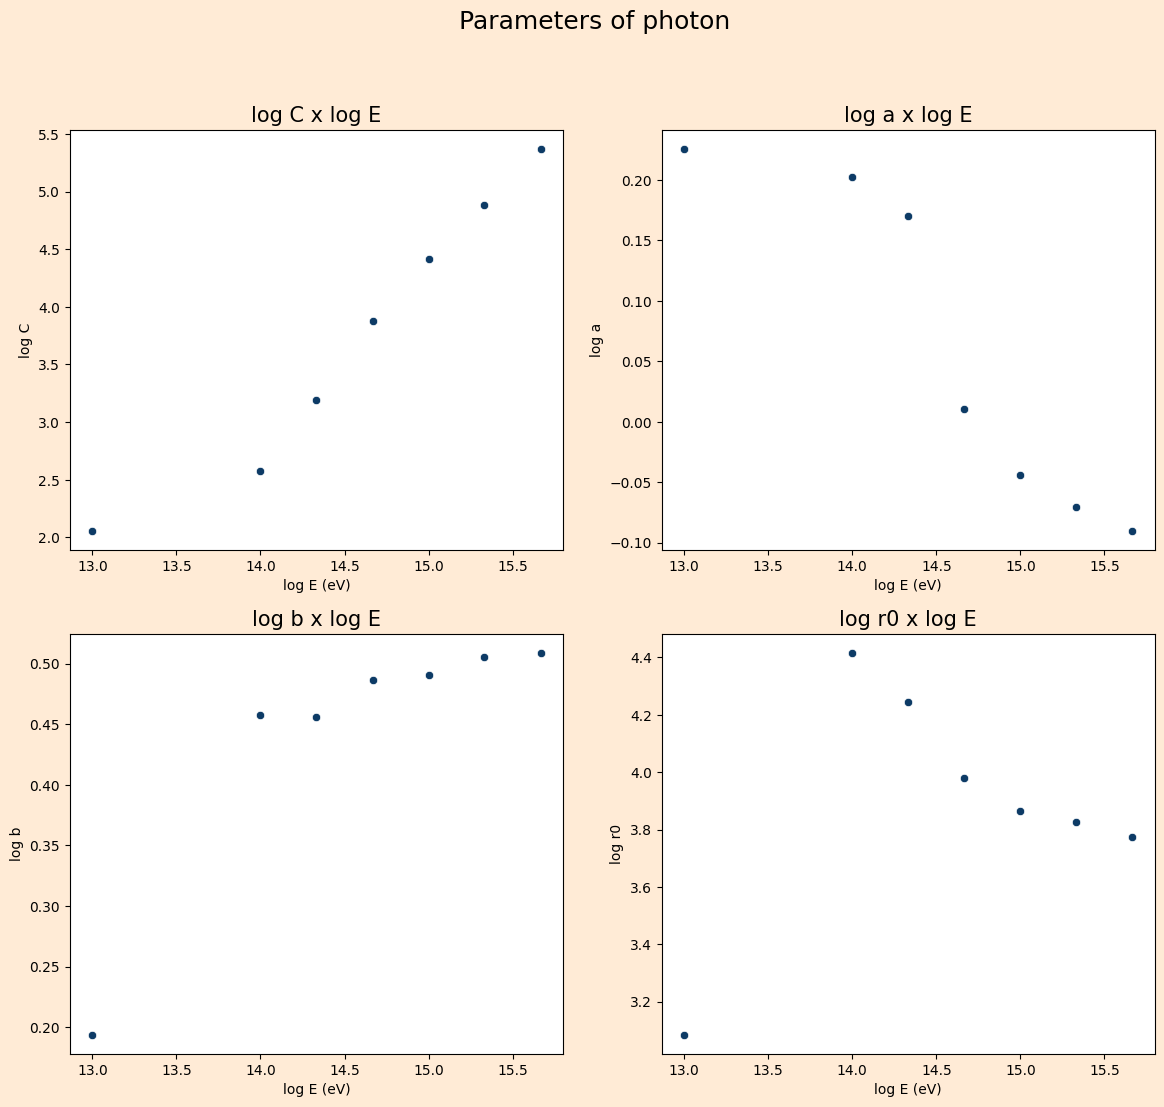

In [101]:
# Fóton

C = [114.6,379.2,1543,7530,2.581E04,7.703E04,2.346E05]
a = [1.681,1.594, 1.479,1.024, 0.9032,0.8501,0.8128]
b = [1.563,2.869, 2.856,3.063, 3.093,3.203,3.228]
r0 = [1217,2.606E04,1.762E04,9531,7307, 6729,5923]
E = [1E13,1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]


logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[  1.67899703 -20.85240436]
[2.65355404 3.21171723 3.77263575 4.33255107 4.89071426 5.45163278]
[2.57886833 3.18836593 3.87679498 4.411788   4.8866599  5.37032801]
[14.         14.33243846 14.66651798 15.         15.33243846 15.66651798]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.578868,14.0,13.955518,0.317731
3.188366,14.332438,14.318531,0.097038
3.876795,14.666518,14.728555,0.422981
4.411788,15.0,15.047193,0.31462
4.88666,15.332438,15.330024,0.015749
5.370328,15.666518,15.618093,0.309096


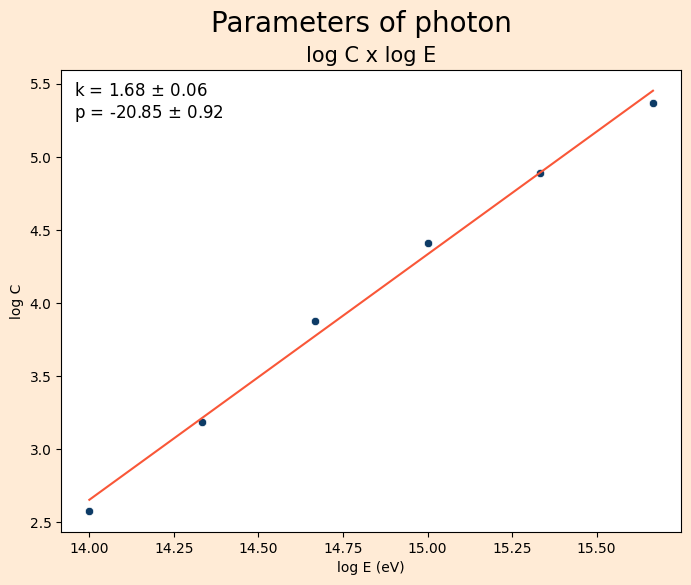

In [121]:
# Fit do fóton

C = [379.2,1543,7530,2.581E04,7.703E04,2.346E05]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
coefficients, cov = np.polyfit(logE, logC, 1, cov = True)
polynomial = np.poly1d(coefficients)
ys = polynomial(logE)

'The standard error on the parameters is the square-root of the diagonal elements'

inc = np.sqrt(np.diag(cov))
#print(np.sqrt(np.diag(cov)))

plt.plot(logE, ys, color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2f} $\pm$ {:.2f}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

print(coefficients)
print(coefficients[0]*logE + coefficients[1])
print(logC)
#print((logC-coefficients[1])/coefficients[0])
print(logE)

logE_0_array = ((logC-coefficients[1])/coefficients[0])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

Text(0, 0.5, 'log r0')

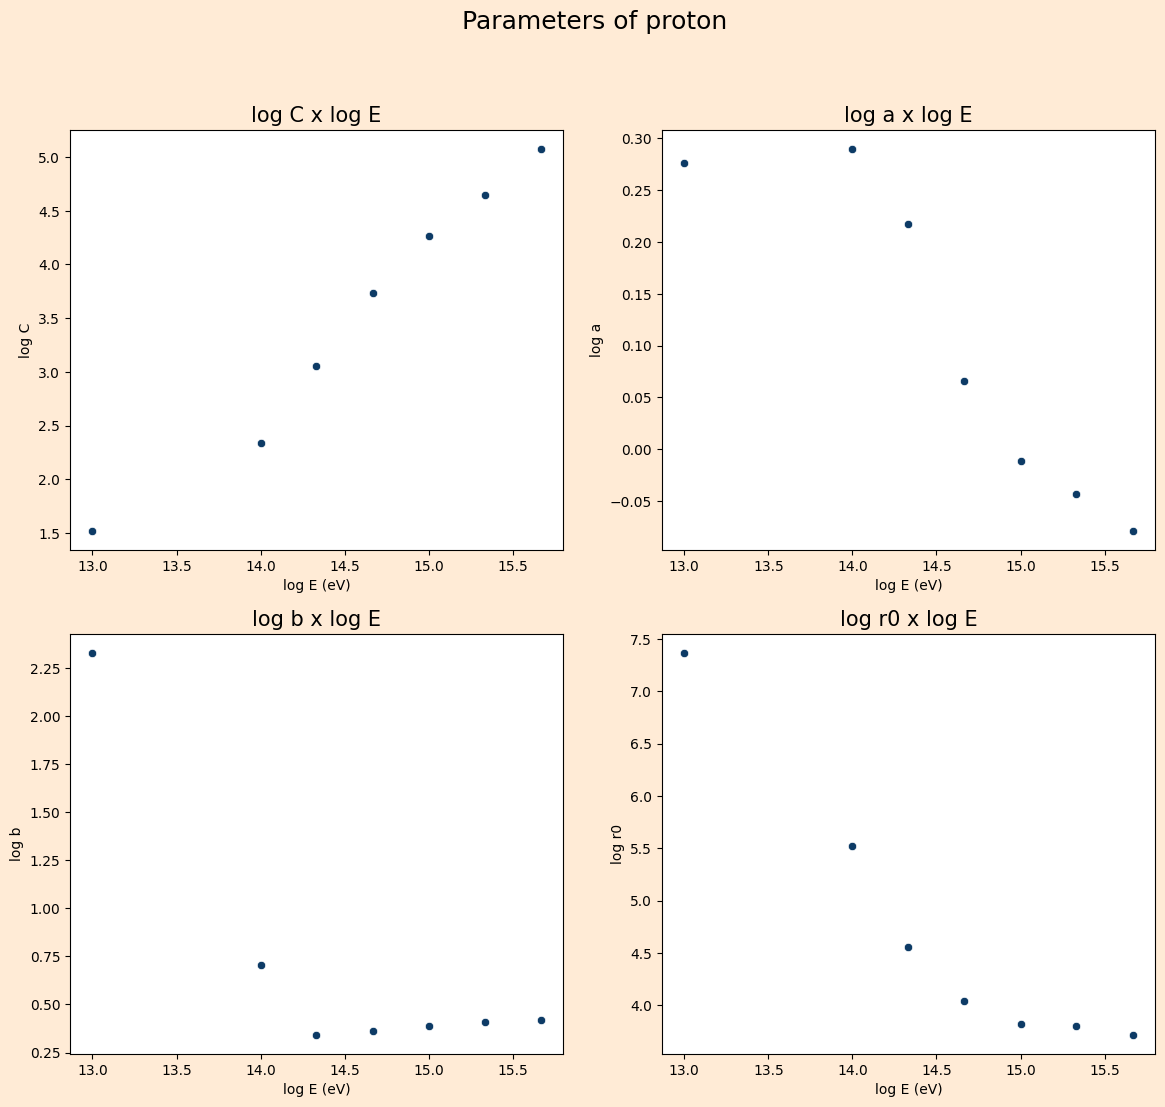

In [122]:
# Próton

C = [33.33,219.9,1130,5392,1.855E04,4.461E04,1.193E05]
a = [1.888,1.949, 1.651,1.164, 0.9753,0.9063,0.8347]
b = [213.7,5.103, 2.204,2.307, 2.452,2.56,2.633]
r0 = [2.339E07,3.348E05,3.596E04,1.084E04,6571, 6315,5214]
E = [1E13,1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]



logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[  1.62846017 -20.30134773]
[2.49709468 3.03845747 3.58249266 4.12555485 4.66691764 5.21095284]
[2.34222523 3.05307844 3.73174988 4.26834391 4.64943222 5.07664044]
[14.         14.33243846 14.66651798 15.         15.33243846 15.66651798]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.342225,14.0,13.904898,0.679298
3.053078,14.332438,14.341417,0.062644
3.73175,14.666518,14.758173,0.62493
4.268344,15.0,15.087683,0.584557
4.649432,15.332438,15.321701,0.070031
5.07664,15.666518,15.58404,0.526461


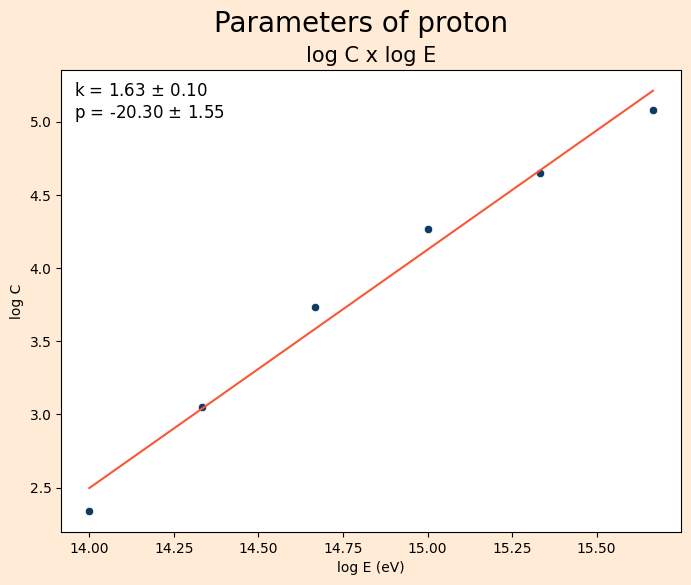

In [124]:
# Fit do próton

C = [219.9,1130,5392,1.855E04,4.461E04,1.193E05]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
coefficients, cov = np.polyfit(logE, logC, 1, cov = True)
polynomial = np.poly1d(coefficients)
ys = polynomial(logE)

'The standard error on the parameters is the square-root of the diagonal elements'

inc = np.sqrt(np.diag(cov))
#print(np.sqrt(np.diag(cov)))

plt.plot(logE, ys, color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2f} $\pm$ {:.2f}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

print(coefficients)
print(coefficients[0]*logE + coefficients[1])
print(logC)
#print((logC-coefficients[1])/coefficients[0])
print(logE)

logE_0_array = ((logC-coefficients[1])/coefficients[0])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

Text(0, 0.5, 'log r0')

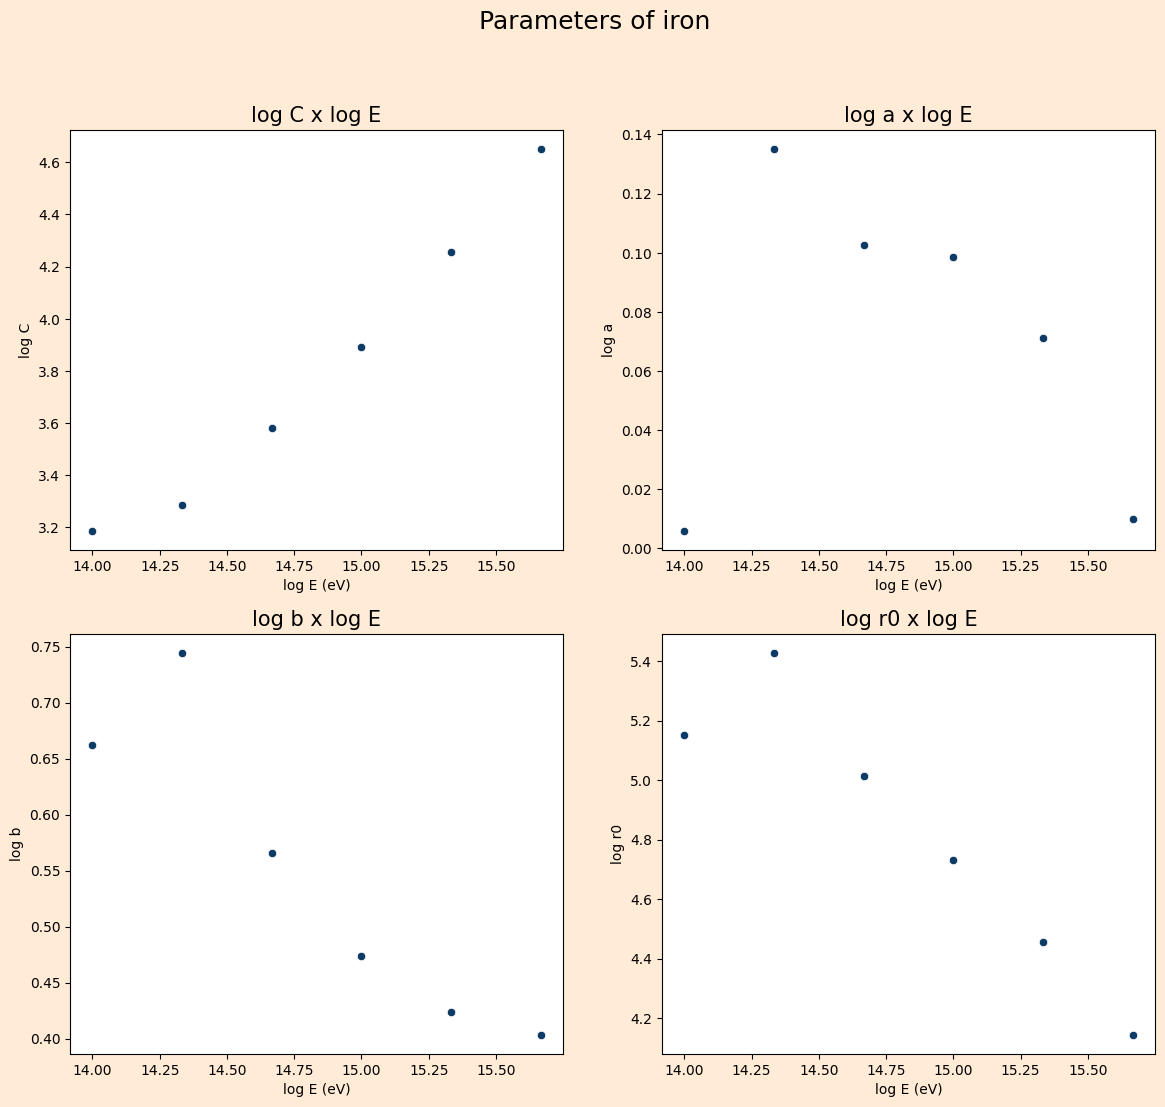

In [128]:
# Ferro

C = [1541,1926,3825,7805,1.796E04,4.481E04]
a = [1.014,1.365, 1.267,1.255, 1.178,1.023]
b = [4.593,5.552, 3.682,2.98, 2.653,2.533]
r0 = [1.417E05,2.68E05,1.034E05,5.37E04,2.847E04, 1.394E04]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[ 0.9032139  -9.58850131]
[3.05649336 3.3567564  3.65850166 3.95970726 4.2599703  4.56171557]
[3.18780264 3.28465628 3.58263144 3.89237291 4.25430633 4.65137494]
[14.         14.33243846 14.66651798 15.         15.33243846 15.66651798]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.187803,14.0,14.14538,1.038429
3.284656,14.332438,14.252612,0.556962
3.582631,14.666518,14.582518,0.572735
3.892373,15.0,14.92545,0.496998
4.254306,15.332438,15.326168,0.0409
4.651375,15.666518,15.765785,0.633625


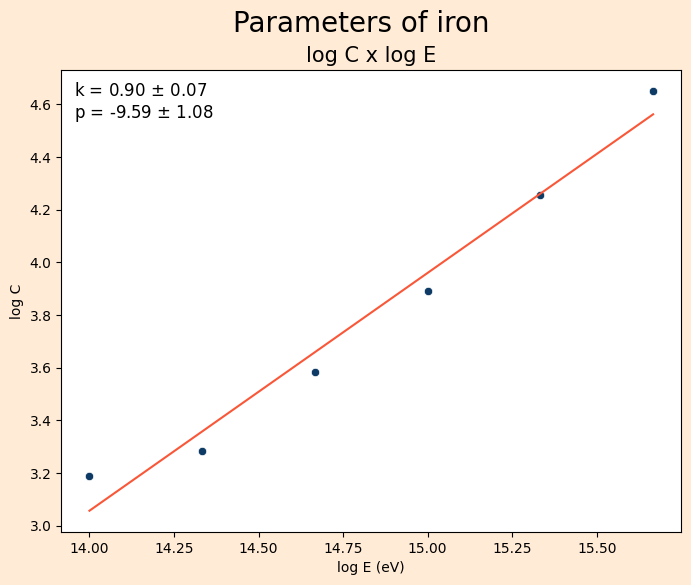

In [126]:
# Fit do ferro

C = [1541,1926,3825,7805,1.796E04,4.481E04]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
coefficients, cov = np.polyfit(logE, logC, 1, cov = True)
polynomial = np.poly1d(coefficients)
ys = polynomial(logE)

'The standard error on the parameters is the square-root of the diagonal elements'

inc = np.sqrt(np.diag(cov))
#print(np.sqrt(np.diag(cov)))

plt.plot(logE, ys, color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2f} $\pm$ {:.2f}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

print(coefficients)
print(coefficients[0]*logE + coefficients[1])
print(logC)
#print((logC-coefficients[1])/coefficients[0])
print(logE)

logE_0_array = ((logC-coefficients[1])/coefficients[0])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df